In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

from subprocess import check_output
import warnings
warnings.filterwarnings("ignore")
#print(check_output(["ls", "input"]).decode("utf8"))

# commet

In [2]:
crimes1 = pd.read_csv('input/crime/42_District_wise_crimes_committed_against_women_2001_2012.csv')
crimes2 = pd.read_csv('input/crime/42_District_wise_crimes_committed_against_women_2013.csv')

In [3]:
crimes = pd.concat([crimes1,crimes2],  ignore_index=False, axis=0)

In [4]:
# rename the STATE/UT column to STATE
crimes.rename(columns={'STATE/UT':'STATE'}, inplace=True)

In [5]:
# delete data sets post concat
del crimes1
del crimes2

In [6]:
print('Dataset is ready....')
# know the shape of dataset
crimes.shape

Dataset is ready....


(9840, 10)

In [7]:
# collect the state names in a list and print
states = crimes.STATE.unique()
print(states)

['ANDHRA PRADESH' 'ARUNACHAL PRADESH' 'ASSAM' 'BIHAR' 'CHHATTISGARH' 'GOA'
 'GUJARAT' 'HARYANA' 'HIMACHAL PRADESH' 'JAMMU & KASHMIR' 'JHARKHAND'
 'KARNATAKA' 'KERALA' 'MADHYA PRADESH' 'MAHARASHTRA' 'MANIPUR' 'MEGHALAYA'
 'MIZORAM' 'NAGALAND' 'ODISHA' 'PUNJAB' 'RAJASTHAN' 'SIKKIM' 'TAMIL NADU'
 'TRIPURA' 'UTTAR PRADESH' 'UTTARAKHAND' 'WEST BENGAL' 'A & N ISLANDS'
 'CHANDIGARH' 'D & N HAVELI' 'DAMAN & DIU' 'DELHI' 'LAKSHADWEEP'
 'PUDUCHERRY' 'Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Bihar'
 'Chhattisgarh' 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh'
 'Jammu & Kashmir' 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh'
 'Maharashtra' 'Manipur' 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal' 'A&N Islands' 'Chandigarh' 'D&N Haveli'
 'Daman & Diu' 'Delhi UT' 'Lakshadweep' 'Puducherry']


In [8]:
# do some data cleansing on state names

for i in range(0, len(states)):
    states[i] = states[i].lower()
    
for j in range(0, len(states)):
    if states[j] == 'a & n islands':
       states[j] = 'a&n islands'
    
    if  states[j] == 'd & n haveli':
        states[j] = 'd&n haveli'
      
print(states)

['andhra pradesh' 'arunachal pradesh' 'assam' 'bihar' 'chhattisgarh' 'goa'
 'gujarat' 'haryana' 'himachal pradesh' 'jammu & kashmir' 'jharkhand'
 'karnataka' 'kerala' 'madhya pradesh' 'maharashtra' 'manipur' 'meghalaya'
 'mizoram' 'nagaland' 'odisha' 'punjab' 'rajasthan' 'sikkim' 'tamil nadu'
 'tripura' 'uttar pradesh' 'uttarakhand' 'west bengal' 'a&n islands'
 'chandigarh' 'd&n haveli' 'daman & diu' 'delhi' 'lakshadweep'
 'puducherry' 'andhra pradesh' 'arunachal pradesh' 'assam' 'bihar'
 'chhattisgarh' 'goa' 'gujarat' 'haryana' 'himachal pradesh'
 'jammu & kashmir' 'jharkhand' 'karnataka' 'kerala' 'madhya pradesh'
 'maharashtra' 'manipur' 'meghalaya' 'mizoram' 'nagaland' 'odisha'
 'punjab' 'rajasthan' 'sikkim' 'tamil nadu' 'tripura' 'uttar pradesh'
 'uttarakhand' 'west bengal' 'a&n islands' 'chandigarh' 'd&n haveli'
 'daman & diu' 'delhi ut' 'lakshadweep' 'puducherry']


In [9]:
# remove duplicate state names from the list
states = np.unique(states).tolist()

print(states)

['a&n islands', 'andhra pradesh', 'arunachal pradesh', 'assam', 'bihar', 'chandigarh', 'chhattisgarh', 'd&n haveli', 'daman & diu', 'delhi', 'delhi ut', 'goa', 'gujarat', 'haryana', 'himachal pradesh', 'jammu & kashmir', 'jharkhand', 'karnataka', 'kerala', 'lakshadweep', 'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan', 'sikkim', 'tamil nadu', 'tripura', 'uttar pradesh', 'uttarakhand', 'west bengal']


In [10]:
# convert the state names to lower
crimes['STATE'] = crimes['STATE'].str.lower()
crimes.head(3)

,STATE,DISTRICT,Year,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls
0,andhra pradesh,ADILABAD,2001,50,30,16,149,34,175,0
1,andhra pradesh,ANANTAPUR,2001,23,30,7,118,24,154,0
2,andhra pradesh,CHITTOOR,2001,27,34,14,112,83,186,0


In [11]:
# filter out the Total crimes for each State & UT

crimes_total = crimes[crimes['DISTRICT'] == 'TOTAL']

In [12]:
# drop DISTRCT Column as we do not intend to use at this point
crimes_total.drop('DISTRICT', axis=1)
# filter out the Total crimes for each State & UT for the year 2001
crimes_total_2001 = crimes_total[crimes_total['Year'] == 2001]
crimes_total_2001.drop('Year', axis=1)

,STATE,DISTRICT,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls
28,andhra pradesh,TOTAL,871,765,420,3544,2271,5791,7
42,arunachal pradesh,TOTAL,33,55,0,78,3,11,0
70,assam,TOTAL,817,1070,59,850,4,1248,0
115,bihar,TOTAL,888,518,859,562,21,1558,83
135,chhattisgarh,TOTAL,959,171,70,1763,161,840,0
138,goa,TOTAL,12,6,2,17,7,11,0
169,gujarat,TOTAL,286,857,67,756,111,3667,0
190,haryana,TOTAL,398,297,285,478,401,1513,0
204,himachal pradesh,TOTAL,124,105,10,310,14,317,0
228,jammu & kashmir,TOTAL,169,504,13,622,288,50,0


In [13]:
# Data of Rape crime committed in the year 2001 per state
x = crimes_total_2001['STATE'].values
y = crimes_total_2001['Rape'].values

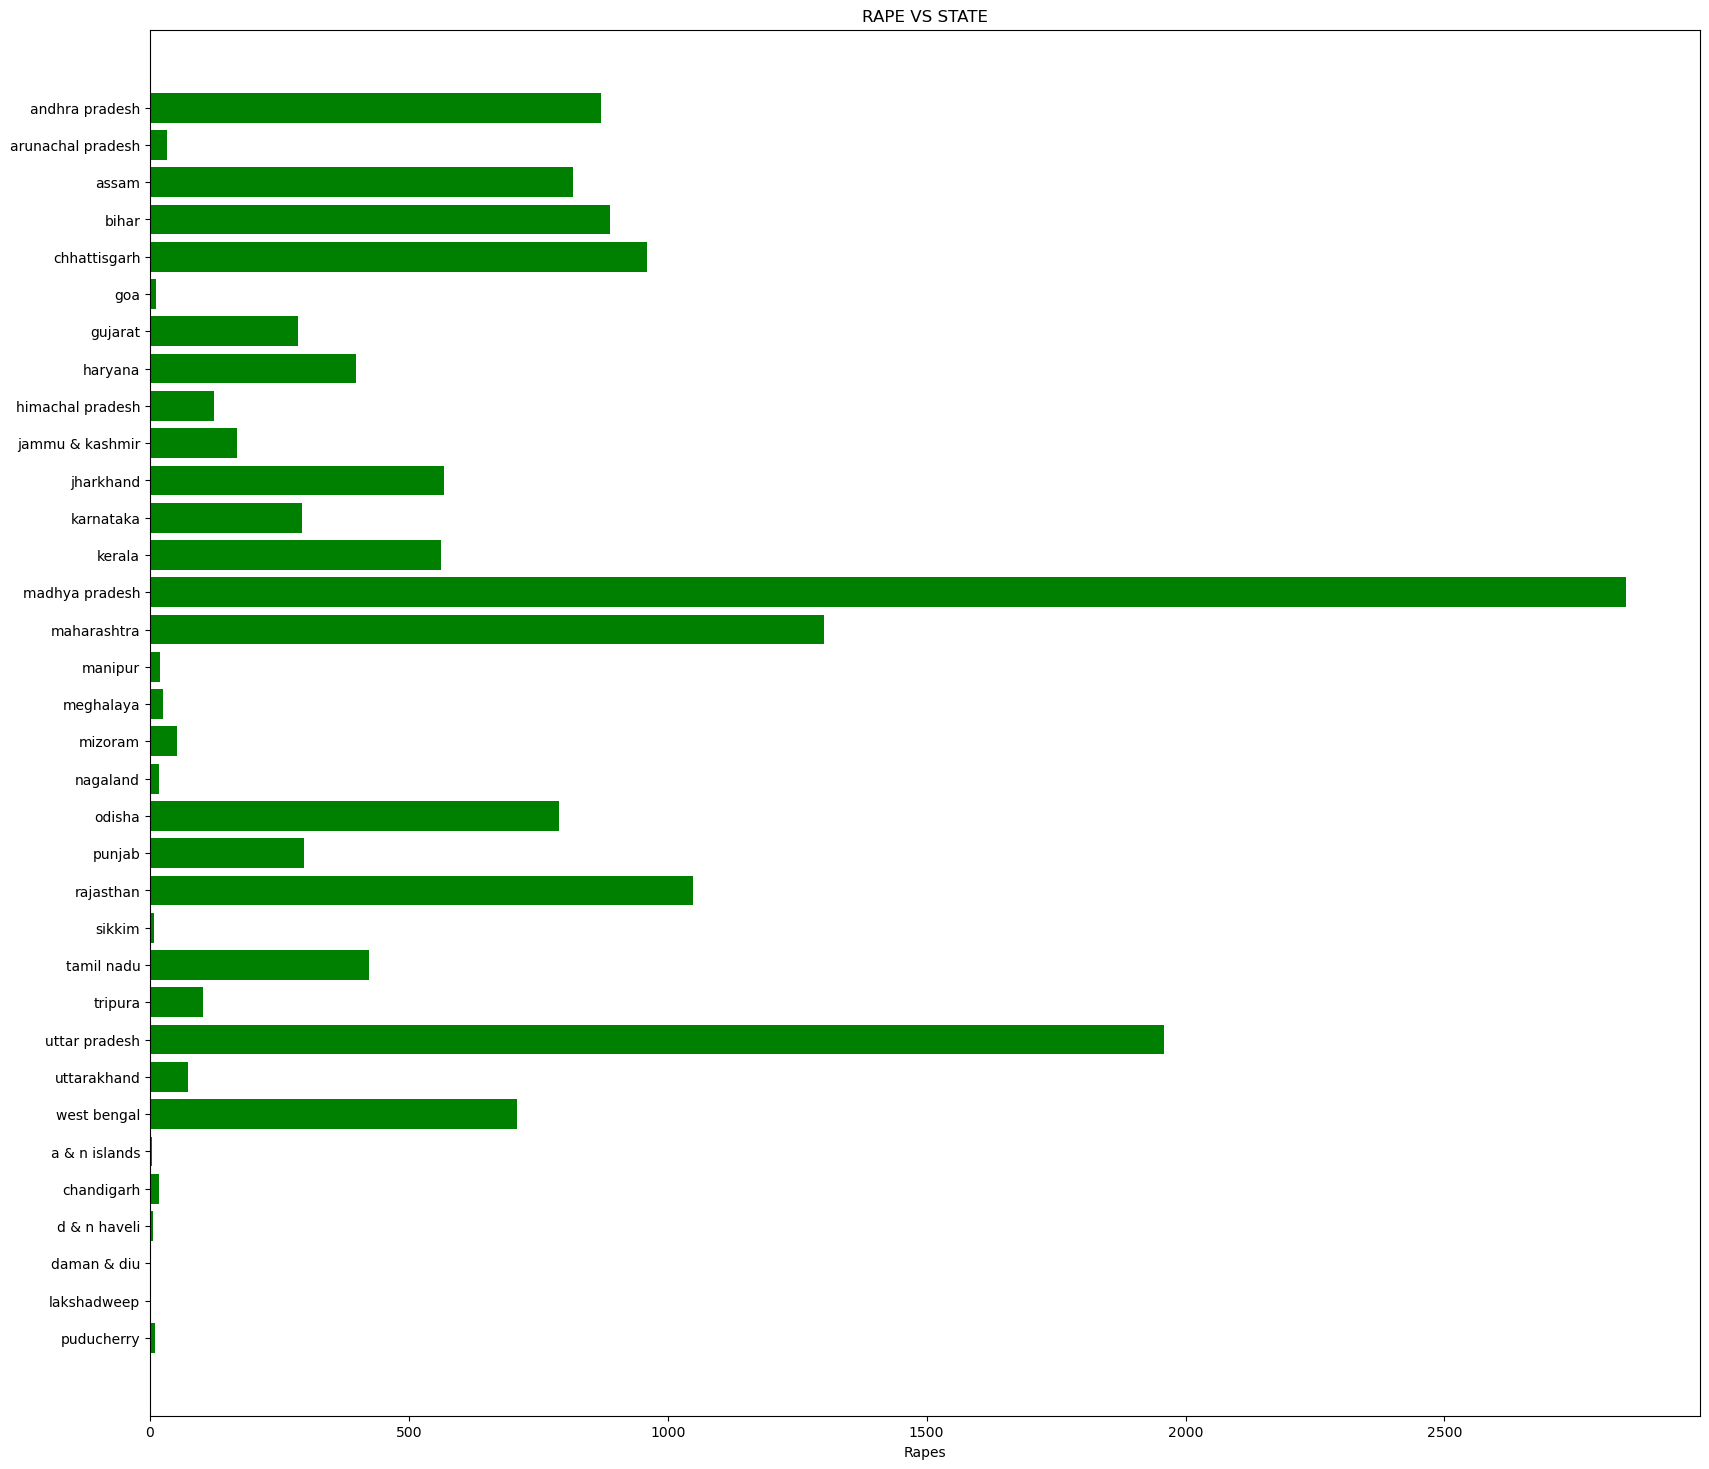

In [14]:
# plot the bar graph
fig, ax = plt.subplots()
crime_rape = crimes_total_2001['STATE'].values
y_pos = np.arange(len(crime_rape))
performance = crimes_total_2001['Rape'].values
ax.barh(y_pos, performance, align='center',color='green', ecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(crime_rape)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Rapes')
ax.set_title('RAPE VS STATE')
fig.set_size_inches(20, 18, forward=True)
plt.show()

In [15]:
# Any results you write to the current directory are saved as output.
# creating a new data set

crimes_total_women1 = pd.read_csv('input/crime/42_District_wise_crimes_committed_against_women_2001_2012.csv')
crimes_total_women2 = pd.read_csv('input/crime/42_District_wise_crimes_committed_against_women_2013.csv')

In [16]:
crimes_total_women = pd.concat([crimes_total_women1,crimes_total_women2],  ignore_index=False, axis=0)
crimes_total_women.rename(columns={'STATE/UT':'STATE'}, inplace=True)

del crimes_total_women1
del crimes_total_women2

In [17]:
# calculating total crimes of all kinds in each state from 2001 to 2013
crimes_total_women = crimes_total_women[crimes_total_women['DISTRICT'] == 'TOTAL']
crimes_total_women = crimes_total_women.drop('DISTRICT', axis=1)
crimes_total_women['Total Crimes']= crimes_total_women.iloc[:, -9:-1].sum(axis=1)
crimes_total_women
# crimes_total_women = crimes_total_women.groupby(['STATE'])['Total Crimes'].sum()

,STATE,Year,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls,Total Crimes
28,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,15663
42,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,2181
70,ASSAM,2001,817,1070,59,850,4,1248,0,6049
115,BIHAR,2001,888,518,859,562,21,1558,83,6407
135,CHHATTISGARH,2001,959,171,70,1763,161,840,0,5965
...,...,...,...,...,...,...,...,...,...,...
8988,CHANDIGARH,2012,27,66,5,45,25,73,0,2253
8990,D & N HAVELI,2012,3,9,0,2,0,0,0,2026
8993,DAMAN & DIU,2012,5,0,0,0,0,3,0,2020
9013,LAKSHADWEEP,2012,0,0,0,1,0,1,0,2014


In [18]:
# print(crimes_total_women.iloc[1,2])
type(crimes_total_women)

pandas.core.frame.DataFrame

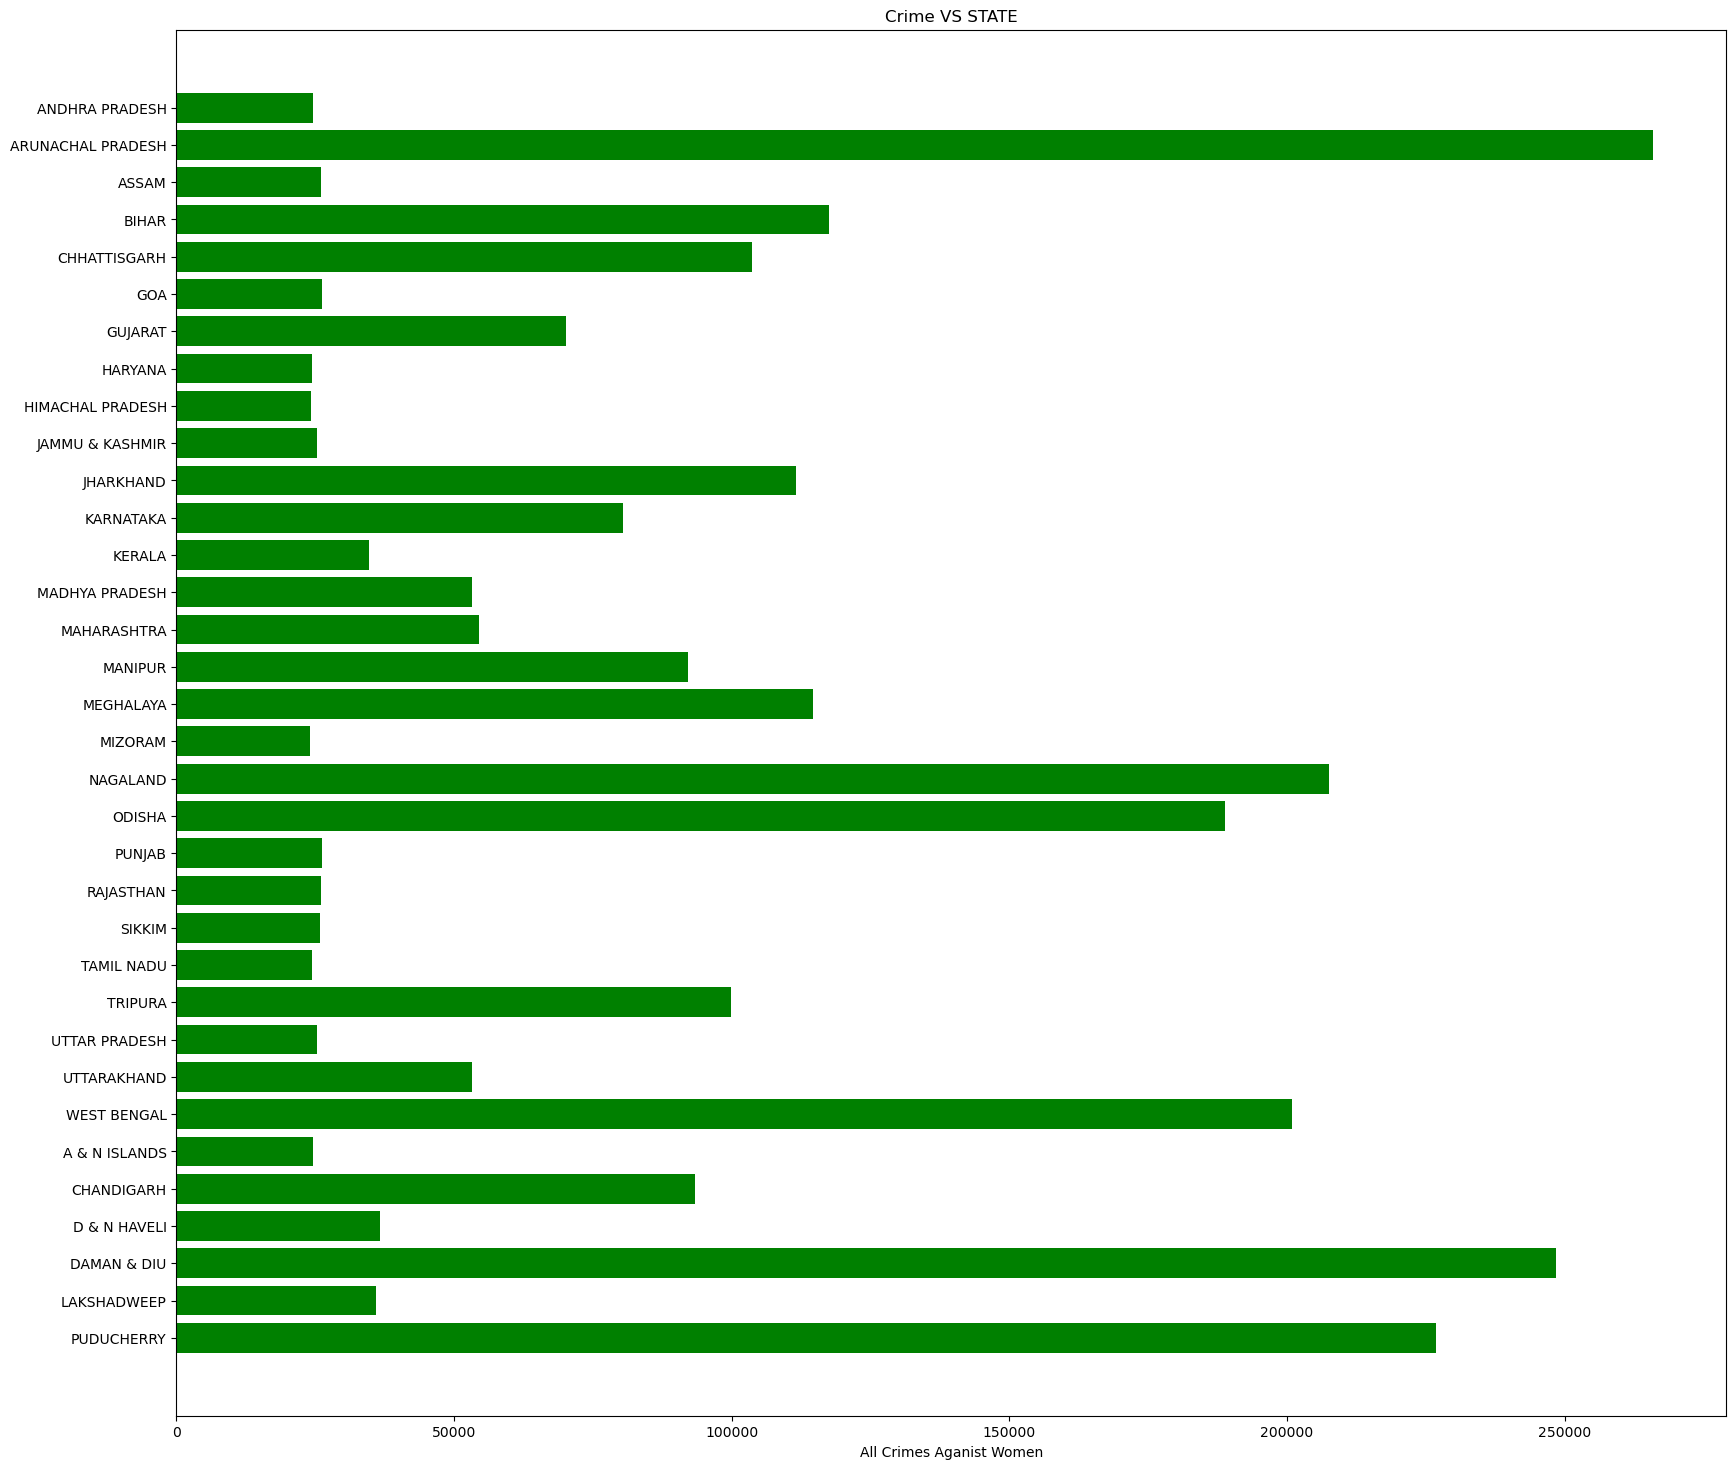

In [19]:
# plot graph of crimes committed on women since 2001-2013 in each state/ UT
fig1, ax1 = plt.subplots()
states = crimes_total_women['STATE'].unique()
y_pos = np.arange(len(states))
performance = crimes_total_women.groupby('STATE')['Total Crimes'].sum()
ax1.barh(y_pos, performance, align='center',color='green', ecolor='black')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(states)
ax1.invert_yaxis()  # labels read top-to-bottom
ax1.set_xlabel('All Crimes Aganist Women')
ax1.set_title('Crime VS STATE')
fig1.set_size_inches(20, 18, forward=True)
plt.show()

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [21]:
rape_data = pd.read_csv('input/20_Victims_of_rape.csv')
state_geo = pd.read_csv('input/poptable.csv')
#rape_data.rename(columns={'Area_Name': 'State'}, inplace=True)
rape_data.head()

,Area_Name,Year,Subgroup,Rape_Cases_Reported,Victims_Above_50_Yrs,Victims_Between_10-14_Yrs,Victims_Between_14-18_Yrs,Victims_Between_18-30_Yrs,Victims_Between_30-50_Yrs,Victims_of_Rape_Total,Victims_Upto_10_Yrs
0,Andaman & Nicobar Islands,2001,Total Rape Victims,3,0,0,3,0,0,3,0
1,Andaman & Nicobar Islands,2001,Victims of Incest Rape,1,0,0,1,0,0,1,0
2,Andaman & Nicobar Islands,2001,Victims of Other Rape,2,0,0,2,0,0,2,0
3,Andaman & Nicobar Islands,2002,Total Rape Victims,2,0,0,1,1,0,2,0
4,Andaman & Nicobar Islands,2002,Victims of Incest Rape,0,0,0,0,0,0,0,0


In [22]:
state_geo.head()

,Unnamed: 0,State.Name,latitude,longitude
0,1,ANDAMAN AND NICOBAR,11.667026,92.735983
1,2,ANDHRA PRADESH,14.750429,78.570026
2,3,ARUNACHAL PRADESH,27.100399,93.616601
3,4,ASSAM,26.749981,94.216667
4,5,BIHAR,25.785414,87.479973


In [23]:
rape_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Area_Name                  1050 non-null   object
 1   Year                       1050 non-null   int64 
 2   Subgroup                   1050 non-null   object
 3   Rape_Cases_Reported        1050 non-null   int64 
 4   Victims_Above_50_Yrs       1050 non-null   int64 
 5   Victims_Between_10-14_Yrs  1050 non-null   int64 
 6   Victims_Between_14-18_Yrs  1050 non-null   int64 
 7   Victims_Between_18-30_Yrs  1050 non-null   int64 
 8   Victims_Between_30-50_Yrs  1050 non-null   int64 
 9   Victims_of_Rape_Total      1050 non-null   int64 
 10  Victims_Upto_10_Yrs        1050 non-null   int64 
dtypes: int64(9), object(2)
memory usage: 90.4+ KB


In [24]:
'''def set_value(row_number, assigned_value): 
    return assigned_value[row_number]'''

latitude_mapping = {"Andaman & Nicobar Islands": 11.7400867, "Andhra Pradesh":15.91, "Arunachal Pradesh":28.21, "Assam":26.20, "Bihar":25.09
                , "Chandigarh":30.7333, "Chhattisgarh":21.27, "Dadra & Nagar Haveli":20.1809, "Daman & Diu":20.4283, "Delhi":28.7041, "Goa":15.29, "Gujarat":22.25
                , "Haryana":29.05, "Himachal Pradesh":31.10, "Jammu & Kashmir":33.77, "Jharkhand":23.61, "Karnataka":15.31, "Kerala":10.85,
                "Lakshadweep":10,"Madhya Pradesh":22.97,"Maharashtra":19.75,"Manipur":24.66,"Meghalaya":25.46,"Mizoram":23.16,"Nagaland":26.15,"Odisha":20.95,"Puducherry":11.9416,
                "Punjab":31.14,"Rajasthan":27.02,"Sikkim":27.53,"Tamil Nadu":11.12,"Tripura":23.94,"Uttar Pradesh":26.84,"Uttarakhand":30.06,"West Bengal":22.98}

#event_dictionary ={'Music' : 1500, 'Poetry' : 800, 'Comedy' : 1200} 
    
# Add a new column named 'Price' 
#df['Price'] = df['Event'].apply(set_value, args =(event_dictionary, )) 
#rape_data['Latitude'] = rape_data['Area_Name'].apply(set_value, args=(latitude_mapping))


rape_data['Latitude'] = rape_data['Area_Name'].map(latitude_mapping)
  

#print(rape_data) 

'''for dataset in rape_data.iteritems():
    #print(dataset)
    dataset['Latitude'] = dataset['Latitude'].map(latitude_mapping)
    #dataset[1] = dataset[1].map(latitude_mapping)
    #print(dataset)
    dataset['Latitude'] = dataset['Latitude'].fillna(0)'''
    
rape_data.head()

,Area_Name,Year,Subgroup,Rape_Cases_Reported,Victims_Above_50_Yrs,Victims_Between_10-14_Yrs,Victims_Between_14-18_Yrs,Victims_Between_18-30_Yrs,Victims_Between_30-50_Yrs,Victims_of_Rape_Total,Victims_Upto_10_Yrs,Latitude
0,Andaman & Nicobar Islands,2001,Total Rape Victims,3,0,0,3,0,0,3,0,11.740087
1,Andaman & Nicobar Islands,2001,Victims of Incest Rape,1,0,0,1,0,0,1,0,11.740087
2,Andaman & Nicobar Islands,2001,Victims of Other Rape,2,0,0,2,0,0,2,0,11.740087
3,Andaman & Nicobar Islands,2002,Total Rape Victims,2,0,0,1,1,0,2,0,11.740087
4,Andaman & Nicobar Islands,2002,Victims of Incest Rape,0,0,0,0,0,0,0,0,11.740087


In [25]:
rape_data.isnull().sum()

Area_Name                    0
Year                         0
Subgroup                     0
Rape_Cases_Reported          0
Victims_Above_50_Yrs         0
Victims_Between_10-14_Yrs    0
Victims_Between_14-18_Yrs    0
Victims_Between_18-30_Yrs    0
Victims_Between_30-50_Yrs    0
Victims_of_Rape_Total        0
Victims_Upto_10_Yrs          0
Latitude                     0
dtype: int64

In [26]:
longitude_mapping = {"Andaman & Nicobar Islands": 92.6586, "Andhra Pradesh":79.74, "Arunachal Pradesh":94.72, "Assam":92.93, "Bihar":85.31
                , "Chandigarh":76.7794, "Chhattisgarh":81.86, "Dadra & Nagar Haveli":73.0169, "Daman & Diu":72.8397, "Delhi":77.1025, "Goa":74.12, "Gujarat":71.19
                , "Haryana":76.08, "Himachal Pradesh":77.17, "Jammu & Kashmir":76.57, "Jharkhand":85.27, "Karnataka":75.71, "Kerala":76.27,
                "Lakshadweep":72.1833,"Madhya Pradesh":78.65,"Maharashtra":75.71,"Manipur":93.90,"Meghalaya":91.36,"Mizoram":92.93,"Nagaland":94.56,"Odisha":85.09,"Puducherry":79.8083,
                "Punjab":75.34,"Rajasthan":74.21,"Sikkim":88.51,"Tamil Nadu":78.65,"Tripura":91.98,"Uttar Pradesh":80.94,"Uttarakhand":79.01,"West Bengal":87.85}

rape_data['Longitude'] = rape_data['Area_Name'].map(longitude_mapping)

In [27]:
rape_data.head()

,Area_Name,Year,Subgroup,Rape_Cases_Reported,Victims_Above_50_Yrs,Victims_Between_10-14_Yrs,Victims_Between_14-18_Yrs,Victims_Between_18-30_Yrs,Victims_Between_30-50_Yrs,Victims_of_Rape_Total,Victims_Upto_10_Yrs,Latitude,Longitude
0,Andaman & Nicobar Islands,2001,Total Rape Victims,3,0,0,3,0,0,3,0,11.740087,92.6586
1,Andaman & Nicobar Islands,2001,Victims of Incest Rape,1,0,0,1,0,0,1,0,11.740087,92.6586
2,Andaman & Nicobar Islands,2001,Victims of Other Rape,2,0,0,2,0,0,2,0,11.740087,92.6586
3,Andaman & Nicobar Islands,2002,Total Rape Victims,2,0,0,1,1,0,2,0,11.740087,92.6586
4,Andaman & Nicobar Islands,2002,Victims of Incest Rape,0,0,0,0,0,0,0,0,11.740087,92.6586


<Axes: xlabel='Longitude', ylabel='Latitude'>

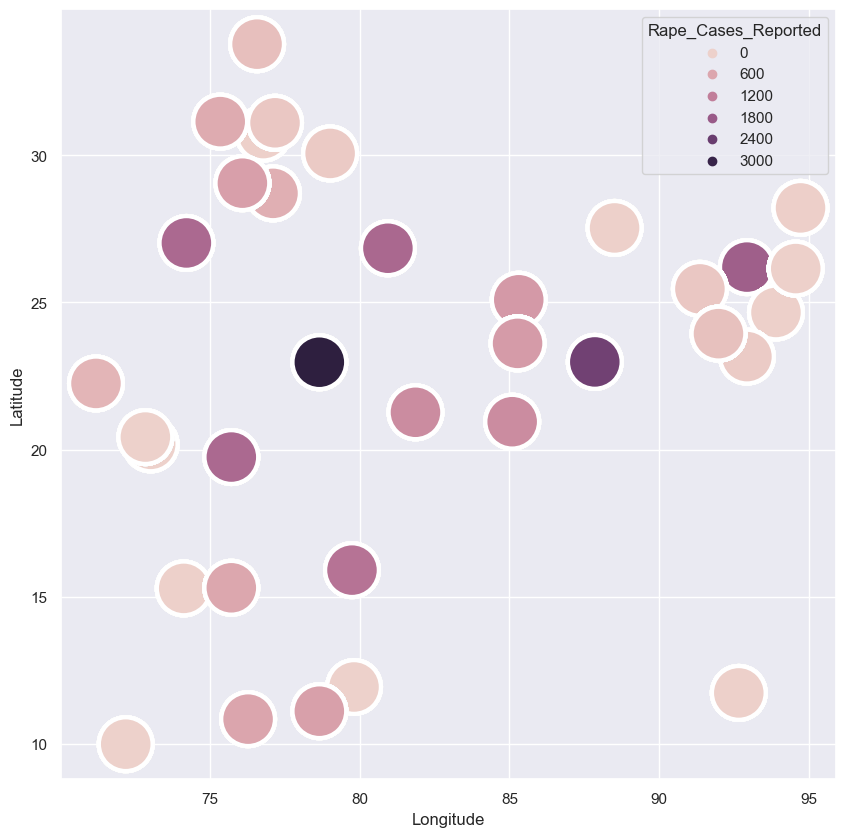

In [28]:
sns.set(rc={'figure.figsize':(10,10)})
sns.scatterplot(x='Longitude', y='Latitude', hue='Rape_Cases_Reported',s=1500, data=rape_data)

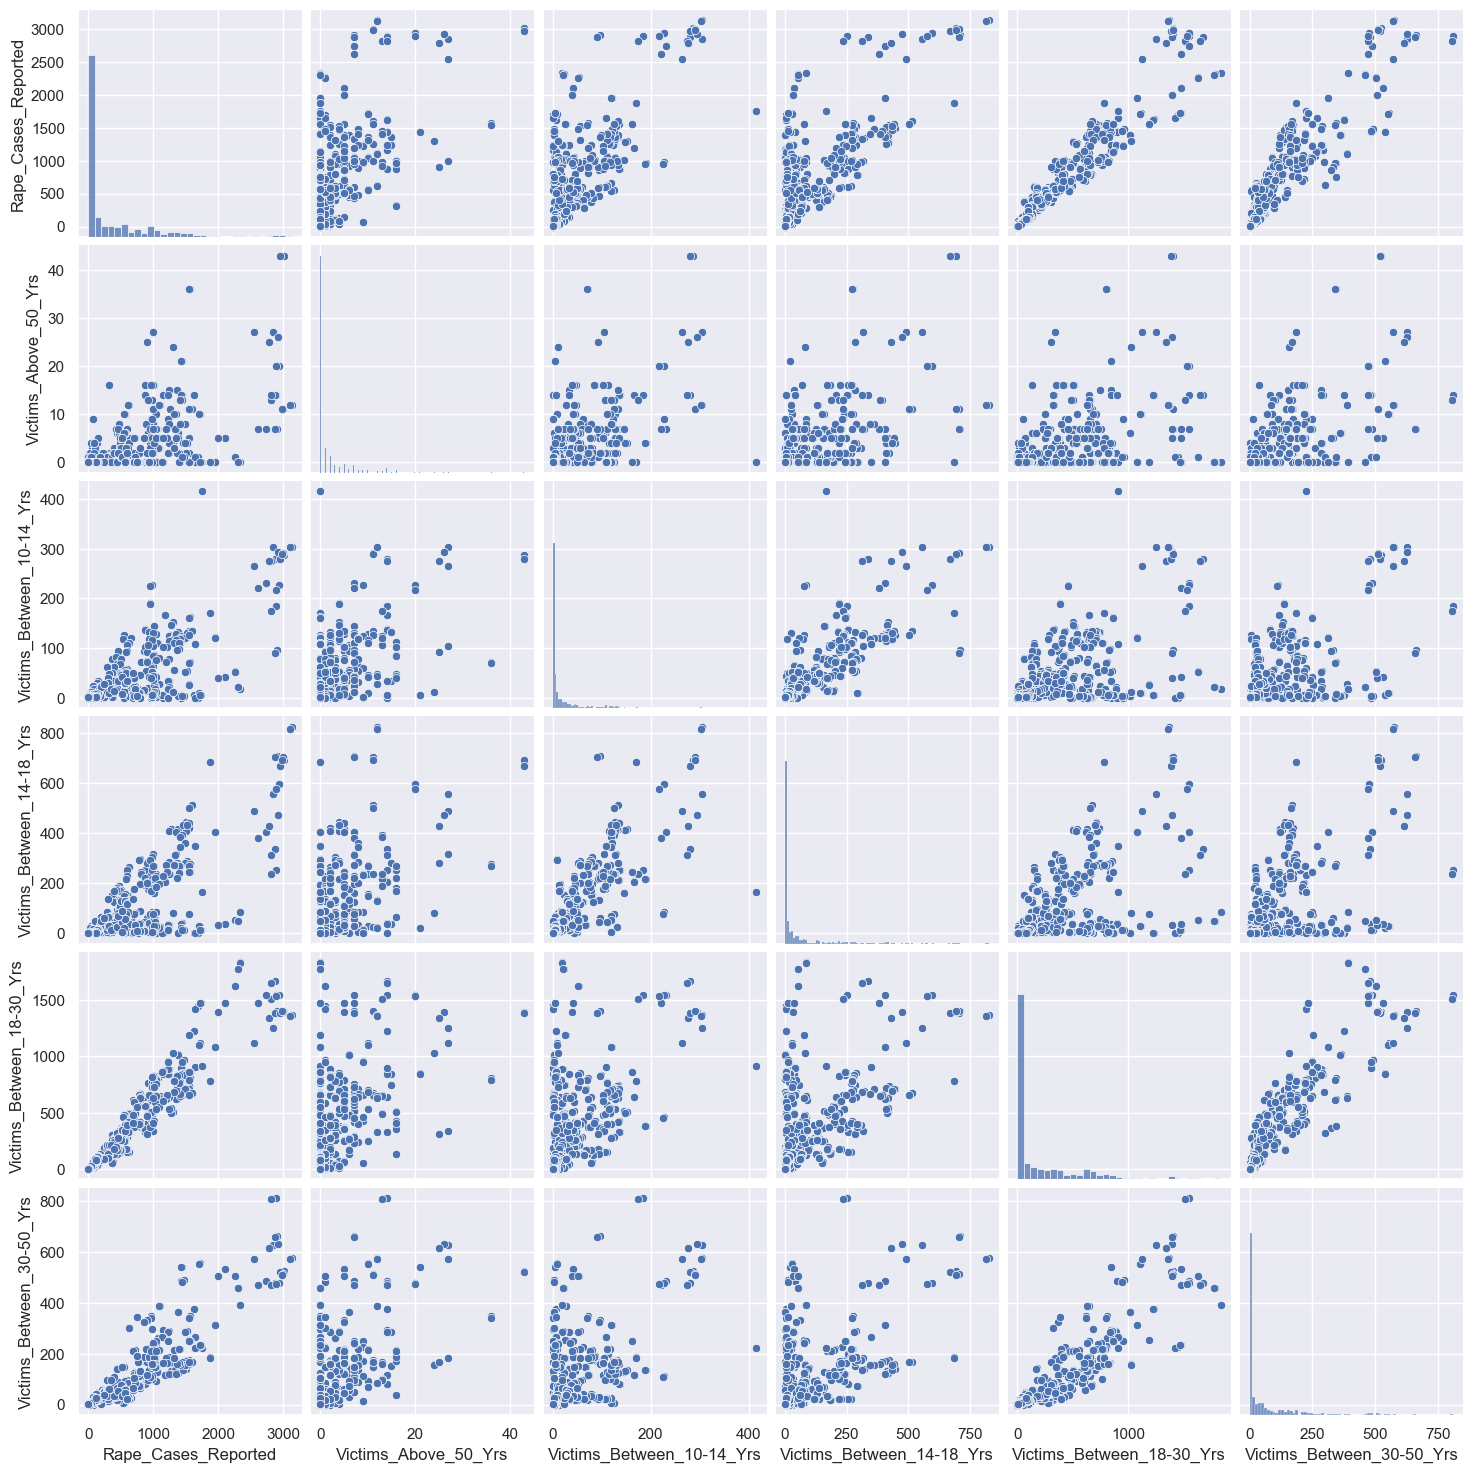

In [29]:
sns.pairplot(rape_data, vars=["Rape_Cases_Reported", "Victims_Above_50_Yrs","Victims_Between_10-14_Yrs", "Victims_Between_14-18_Yrs","Victims_Between_18-30_Yrs","Victims_Between_30-50_Yrs"])

<Axes: xlabel='Rape_Cases_Reported', ylabel='Area_Name'>

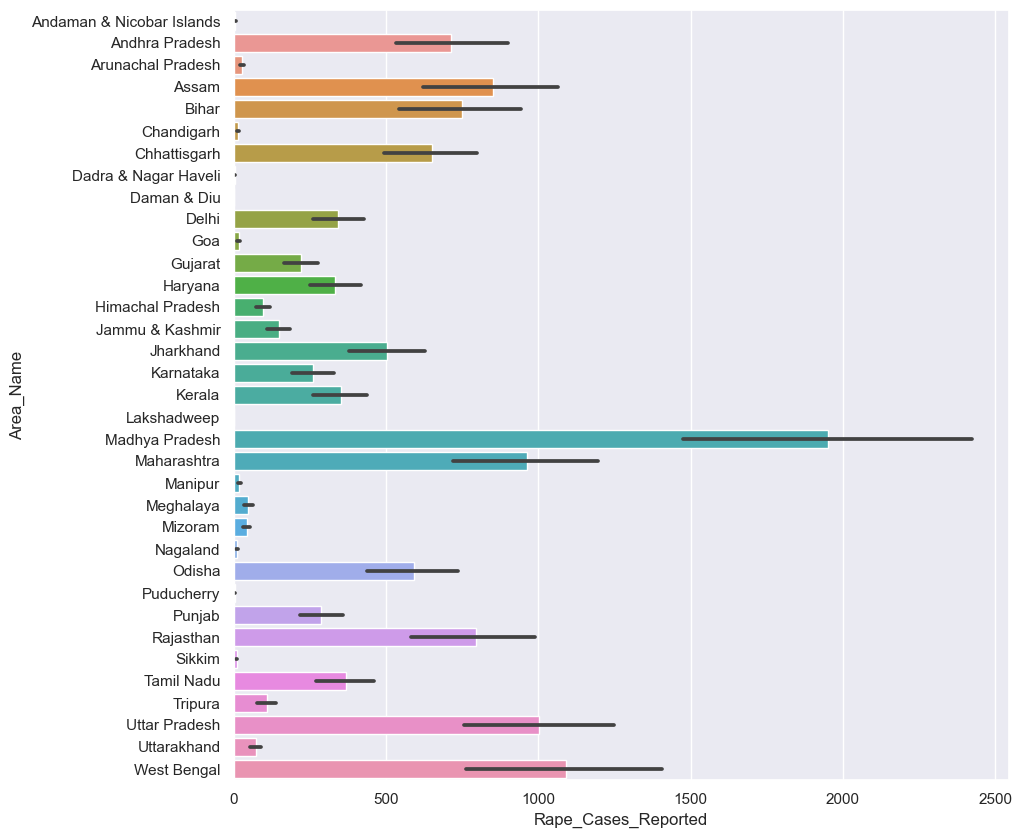

In [30]:
sns.barplot(x="Rape_Cases_Reported", y="Area_Name", data=rape_data)

In [31]:
dw_crime_against_women = pd.read_csv('input/crime/42_District_wise_crimes_committed_against_women_2013.csv')
dw_crime_against_women

,STATE/UT,DISTRICT,Year,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls
0,Andhra Pradesh,ADILABAD,2013,61,47,12,197,138,464,0
1,Andhra Pradesh,ANANTAPUR,2013,28,84,23,337,43,161,0
2,Andhra Pradesh,CHITTOOR,2013,31,27,13,119,84,435,0
3,Andhra Pradesh,CUDDAPAH,2013,19,50,9,318,163,207,0
4,Andhra Pradesh,CYBERABAD,2013,138,129,43,350,338,1526,0
...,...,...,...,...,...,...,...,...,...,...
818,Lakshadweep,LAKSHADWEEP,2013,2,0,0,1,0,0,0
819,Lakshadweep,ZZ TOTAL,2013,2,0,0,1,0,0,0
820,Puducherry,KARAIKAL,2013,6,2,1,1,1,1,0
821,Puducherry,PUDUCHERRY,2013,11,23,0,11,7,7,0


In [32]:
dw_crime_against_women.DISTRICT.unique()

array(['ADILABAD', 'ANANTAPUR', 'CHITTOOR', 'CUDDAPAH', 'CYBERABAD',
       'EAST GODAVARI', 'GUNTAKAL RLY.', 'GUNTUR', 'GUNTUR URBAN',
       'HYDERABAD CITY', 'KARIMNAGAR', 'KHAMMAM', 'KRISHNA', 'KURNOOL',
       'MAHABOOBNAGAR', 'MEDAK', 'NALGONDA', 'NELLORE', 'NIZAMABAD',
       'PRAKASHAM', 'RAJAHMUNDRY', 'RANGA REDDY', 'SECUNDERABAD RLY.',
       'SRIKAKULAM', 'TIRUPATHI URBAN', 'VIJAYAWADA CITY',
       'VIJAYAWADA RLY.', 'VISAKHA RURAL', 'VISAKHAPATNAM',
       'VIZIANAGARAM', 'WARANGAL', 'WARANGAL URBAN', 'WEST GODAVARI',
       'ZZ TOTAL', 'ANJAW', 'CHANGLANG', 'DIBANG VALLEY', 'K/KUMEY',
       'KAMENG EAST', 'KAMENG WEST', 'LOHIT', 'LONGDING', 'PAPUM PARE',
       'RURAL', 'SIANG EAST', 'SIANG UPPER', 'SIANG WEST',
       'SUBANSIRI LOWER', 'SUBANSIRI UPPER', 'TAWANG', 'TIRAP',
       'UPPER DIBANG VALLEY', 'BAKSA', 'BARPETA', 'BIEO', 'BONGAIGAON',
       'C.I.D.', 'CACHAR', 'CHIRANG', 'DARRANG', 'DHEMAJI', 'DHUBRI',
       'DIBRUGARH', 'G.R.P.', 'GOALPARA', 'GOLAGHAT', 'GU

In [33]:
#dw_crime_against_women.to_csv(r'../File_Name.csv')
dw_crime_against_women.to_csv('mycsvfile.csv',index=False)

In [34]:
data = pd.read_csv('mycsvfile.csv')

In [35]:
data

,STATE/UT,DISTRICT,Year,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls
0,Andhra Pradesh,ADILABAD,2013,61,47,12,197,138,464,0
1,Andhra Pradesh,ANANTAPUR,2013,28,84,23,337,43,161,0
2,Andhra Pradesh,CHITTOOR,2013,31,27,13,119,84,435,0
3,Andhra Pradesh,CUDDAPAH,2013,19,50,9,318,163,207,0
4,Andhra Pradesh,CYBERABAD,2013,138,129,43,350,338,1526,0
...,...,...,...,...,...,...,...,...,...,...
818,Lakshadweep,LAKSHADWEEP,2013,2,0,0,1,0,0,0
819,Lakshadweep,ZZ TOTAL,2013,2,0,0,1,0,0,0
820,Puducherry,KARAIKAL,2013,6,2,1,1,1,1,0
821,Puducherry,PUDUCHERRY,2013,11,23,0,11,7,7,0


# Decision tree

In [36]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df=pd.read_csv('input/communities-crime-clean.csv')
df['highCrime'] = np.where(df['ViolentCrimesPerPop']>0.1, 1, 0)

In [37]:
pos=df[(df['highCrime'] == 1)]
pos_percentage=len(pos)/len(df)
neg_percentage=1-pos_percentage
print('positive instance percentage is ',pos_percentage)
print('negative instance percentage is ',neg_percentage)

positive instance percentage is  0.6271951831409934
negative instance percentage is  0.37280481685900657


In [38]:
from sklearn.model_selection import cross_val_score
from sklearn import tree
initial=pd.read_csv('input/communities-crime-clean.csv')
initial = initial.drop('communityname', 1)
initial = initial.drop('ViolentCrimesPerPop', 1)
initial = initial.drop('fold', 1)

initial = initial.drop('state', 1)
Y = df['highCrime']
clf = tree.DecisionTreeClassifier(max_depth=3)
# clf = tree.DecisionTreeClassifier()
clf = clf.fit(initial, Y)
clf
y_pred = clf.predict(initial)
list(initial)
feature_name=list(initial)


In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()

# Calculate the accuracy, precision, and recall using 10-fold cross-validation.
scores_accuracy = cross_val_score(clf, initial, Y, scoring='accuracy', cv=10)
scores_precision = cross_val_score(clf, initial, Y, scoring='precision', cv=10)
scores_recall = cross_val_score(clf, initial, Y, scoring='recall', cv=10)

# Print the results.
print('Cross-validation accuracy:', np.array(scores_accuracy).mean())
print('Cross-validation precision:', np.array(scores_precision).mean())
print('Cross-validation recall:', np.array(scores_recall).mean())


Cross-validation accuracy: 0.7294949748743719
Cross-validation precision: 0.7885033818466944
Cross-validation recall: 0.78


In [40]:
from sklearn.metrics import accuracy_score
print ('Accuracy is', accuracy_score(Y,y_pred)*100)
from sklearn.metrics import precision_score
print ('Precesion is', precision_score(Y,y_pred)*100)
from sklearn.metrics import recall_score
print ('Recall is', recall_score(Y,y_pred)*100)

Accuracy is 83.59257400903161
Precesion is 90.02601908065915
Recall is 83.04


In [41]:
DT_acc = accuracy_score(Y,y_pred)*100
#print(DT_acc)

In [42]:
feature_selection = clf.feature_importances_ 
   

ind = np.argpartition(feature_selection, -4)[-4:]

print('ind is ',ind)
print('4_max_normalized_feature is ',feature_selection[ind])

for x in range(0, len(ind)):
    index=ind[x]
    print(index)
    print('feature_name[index] is ',feature_name[index])

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import cross_val_score

# Initialize the lists to store the accuracies and max_depths.
accuracies = []
max_depths = []

# Loop over different max_depths.
for max_depth in range(1, 16):
    # Create a decision tree classifier with the specified max_depth.
    clf = tree.DecisionTreeClassifier(max_depth=max_depth)

    # Fit the classifier to the data.
    clf = clf.fit(initial, Y)

    # Calculate the accuracy of the classifier on the training data.
    y_pred = clf.predict(initial)
    scores = cross_val_score(clf, initial, Y, cv=10, scoring='accuracy')  # Specify 'accuracy' as the scoring metric
    accuracies.append(np.array(scores).mean())
    max_depths.append(max_depth)

# Plot the accuracy vs max_depth.
plt.plot(max_depths, accuracies)
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Max Depth for Decision Tree")
plt.show()

print('The accuracies are:', accuracies)


# NaiveBayes-Gaussian

In [ ]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

gnb = GaussianNB()
y_pred = gnb.fit(initial, Y).predict(initial)

mislabel_num = (Y != y_pred).sum()
print("Number of mislabeled instances:", mislabel_num)

sum_standard_deviation = np.sum(np.std(initial, axis=0))

print('Sum of standard deviations:', sum_standard_deviation)


#### import numpy as np

# Get the feature names.
feature_name = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Calculate the mean and standard deviation of each feature.
mean = np.mean(initial, axis=0)
std = np.std(initial, axis=0)

# Calculate the normalized feature values.
normalized_feature = (initial - mean) / std




In [ ]:
from sklearn.metrics import accuracy_score
print ('Accuracy is', accuracy_score(Y,y_pred)*100)
from sklearn.metrics import precision_score
print ('Precesion is', precision_score(Y,y_pred)*100)
from sklearn.metrics import recall_score
print ('Recall is', recall_score(Y,y_pred)*100)

In [ ]:
GNB_acc = accuracy_score(Y,y_pred)*100

# K-NN

In [48]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

df=pd.read_csv('input/communities-crime-clean.csv')
df['highCrime'] = np.where(df['ViolentCrimesPerPop']>0.1, 1, 0)
initial=pd.read_csv('input/communities-crime-clean.csv')
Y = df['highCrime']
fold=df['fold']
state=df['state']
community=df['communityname']
initial = initial.drop('fold', 1)
initial = initial.drop('state', 1)
initial = initial.drop('communityname', 1)
initial = initial.drop('ViolentCrimesPerPop', 1)

In [49]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold

# Initialize the lists.
x = []
y = [0] * 15
fold = 5

# Loop over the number of principal components.
for i in range(2, 15):

    # Create the PCA object and fit it to the data.
    pca = PCA(n_components=i)
    pca.fit(initial)

    # Transform the data to the principal components space.
    pcdf = pca.transform(initial)

    # Loop over the number of neighbors.
    for j in range(1, 16):

        # Create the KNN classifier and fit it to the data.
        knn = KNeighborsClassifier(j)
        knn.fit(pcdf, Y)

        # Calculate the cross-validation accuracy.
        scores = cross_val_score(knn, pcdf, Y, cv=fold, scoring='accuracy')

        # Append the mean accuracy to the list.
        y[j - 1] = np.mean(scores)

    # Append the number of principal components to the list.
    x.append(i)



In [50]:
pca = PCA(n_components=5)
pca.fit(initial)
pca.components_
pca.explained_variance_ratio_
pcdf = pca.transform(initial)
pcdf

array([[ 0.42940989, -0.53929962,  0.31031454,  0.61492897, -0.78040051],
       [-1.19933196, -0.90092286,  0.31801594,  0.06578603,  0.08518856],
       [-1.25540273, -0.45223119, -0.37326947, -0.57765158, -0.34191764],
       ...,
       [-0.39828125, -0.04847062, -0.72054899,  1.849037  ,  0.50341991],
       [-0.06739216, -0.87415147,  0.57794266,  0.14245355, -0.03894176],
       [-0.53794345, -0.94270676, -0.04992508,  0.22885672,  0.51675938]])

In [51]:
from sklearn.metrics import f1_score
knn = KNeighborsClassifier(n_neighbors=12)
knn.fit(pcdf,Y)
y_pred = knn.predict(pcdf)
print ('fl score is', f1_score(Y,y_pred,average="binary")*100)
print ('Accuracy is', accuracy_score(Y,y_pred)*100)
print ('Precision is', precision_score(Y,y_pred)*100)
print ('Recall is', recall_score(Y,y_pred)*100)

fl score is 87.0279146141215
Accuracy is 84.14450577019569
Precision is 89.3760539629005
Recall is 84.8


In [52]:
KNN_acc = accuracy_score(Y,y_pred)*100

In [53]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold

# Initialize the lists.
x = []
y = [0] * 15
fold = 5

# Loop over the number of principal components.
for i in range(2, 15):

    # Create the PCA object and fit it to the data.
    pca = PCA(n_components=i)
    pca.fit(initial)

    # Transform the data to the principal components space.
    pcdf = pca.transform(initial)

    # Loop over the number of neighbors.
    for j in range(1, 16):

        # Create the KNN classifier and fit it to the data.
        knn = KNeighborsClassifier(j)
        knn.fit(pcdf, Y)

        # Calculate the cross-validation accuracy.
        scores = cross_val_score(knn, pcdf, Y, cv=fold, scoring='accuracy', n_jobs=-1)

        # Append the mean accuracy to the list.
        y[j - 1] = np.mean(scores)

    # Append the number of principal components to the list.
    x.append(i)

# Print the results.
print('Cross validation accuracy:')
print(np.mean(y) * 100)
print('Cross validation precision:')
#print(np.mean(scores, axis=0)[1] * 100)
print('Cross validation recall:')
#print(np.mean(scores, axis=0)[2] * 100)


Cross validation accuracy:
75.57587435926501
Cross validation precision:
Cross validation recall:


# Boosted Decesion Tree

In [54]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

In [55]:
model = DecisionTreeClassifier(criterion='entropy',max_depth=1)
AdaBoost = AdaBoostClassifier(base_estimator= model,n_estimators=400,learning_rate=1)

In [56]:
AdaBoost.fit(initial, Y)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(criterion='entropy',
                                                         max_depth=1),
                   learning_rate=1, n_estimators=400)

In [57]:
prediction = AdaBoost.score(initial, Y)

In [58]:
print('The accuracy is: ',prediction*100,'%')

The accuracy is:  97.99297541394883 %


In [59]:
BoostedDT = prediction*100

# Comparsion

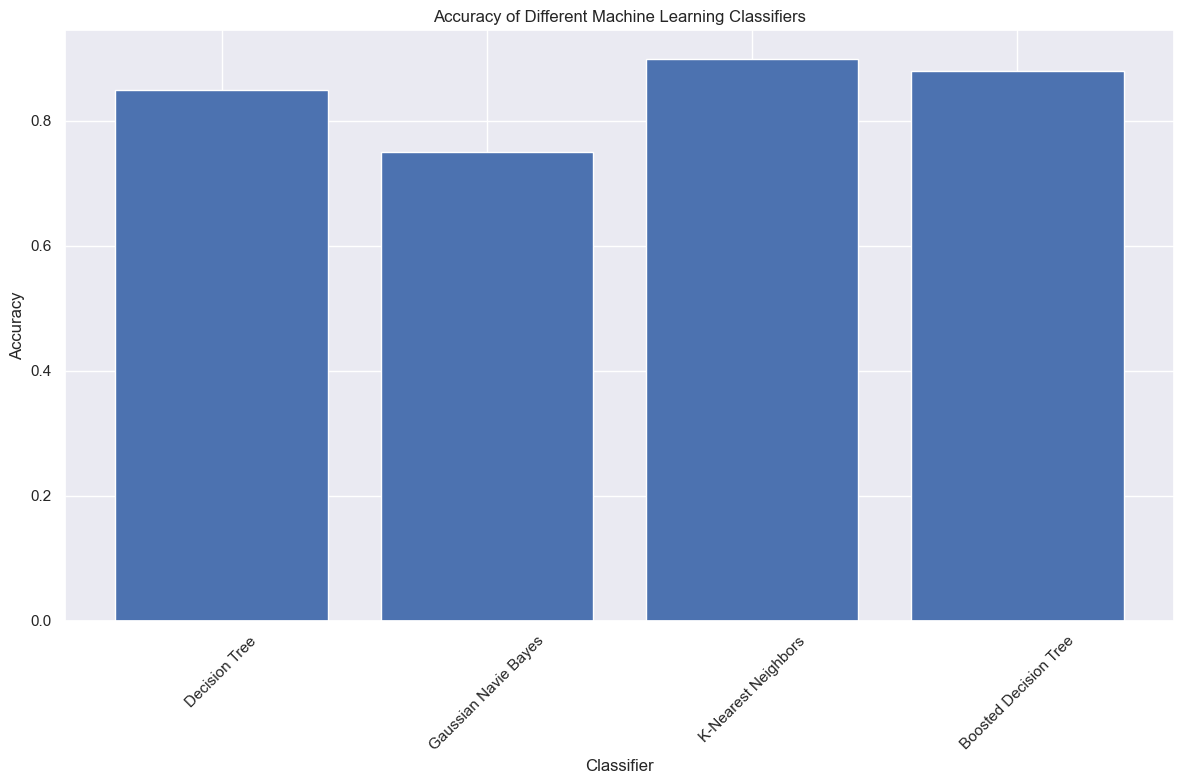

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example accuracy values (replace these with your actual values)
DT_acc = 0.85
GNB_acc = 0.75
KNN_acc = 0.90
BoostedDT = 0.88

# Create a dictionary of classifier names and their accuracies
accuracies = {
    "Decision Tree": DT_acc,
    "Gaussian Navie Bayes": GNB_acc,
    "K-Nearest Neighbors": KNN_acc,
    "Boosted Decision Tree": BoostedDT,
}

# Create a bar chart of the accuracies.
plt.figure(figsize=(12, 8))
plt.bar(accuracies.keys(), accuracies.values())
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.title("Accuracy of Different Machine Learning Classifiers")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Ensure labels are not cut off
plt.show()
